In [149]:
import pinocchio as pin
import numpy as np
import time
import meshcat
import meshcat_shapes
from pinocchio.visualize import MeshcatVisualizer
from robot_descriptions.loaders.pinocchio import load_robot_description

from scipy.linalg import expm
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)

In [150]:
robot = load_robot_description("fetch_description")

print(f"Robot loaded: {robot.model.name}")
print(f"Configuration vector size (nq): {robot.model.nq}")
print(f"Velocity vector size (nv): {robot.model.nv}")

q0 = pin.neutral(robot.model)

for i, name in enumerate(robot.model.names):
    print(f"Joint {i}: {name}")

Robot loaded: fetch
Configuration vector size (nq): 19
Velocity vector size (nv): 14
Joint 0: universe
Joint 1: l_wheel_joint
Joint 2: r_wheel_joint
Joint 3: torso_lift_joint
Joint 4: head_pan_joint
Joint 5: head_tilt_joint
Joint 6: shoulder_pan_joint
Joint 7: shoulder_lift_joint
Joint 8: upperarm_roll_joint
Joint 9: elbow_flex_joint
Joint 10: forearm_roll_joint
Joint 11: wrist_flex_joint
Joint 12: wrist_roll_joint
Joint 13: l_gripper_finger_joint
Joint 14: r_gripper_finger_joint


In [151]:
# Start Meshcat and the visualizer
viz = MeshcatVisualizer(robot.model, robot.collision_model, robot.visual_model)
viz.initViewer(open=True)
viz.loadViewerModel("robot")

# Set a background color for a professional "paper-ready" look
viz.viewer["/Background"].set_property("top_color", [0.9, 0.9, 0.95])
viz.viewer["/Background"].set_property("bottom_color", [1.0, 1.0, 1.0])

# Display the robot in its default pose
viz.display(q0)

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7036/static/


In [152]:
import meshcat.geometry as g
import meshcat.transformations as tf

# Clear the viewer to prevent ghost objects if you re-run the cell.
# Meshcat paths are evaluated lazily, so it is safe to call delete() 
# even if the object doesn't currently exist in the scene.
for name in ["table1", "table2", "apple"]:
    viz.viewer[name].delete()
    
for i in range(10): # Clear up to 10 potential old humans
    viz.viewer[f"human_{i}"].delete()

# Floor
viz.viewer["floor"].set_object(g.Box([10, 10, 0.01]), g.MeshLambertMaterial(color=0xdddddd))
viz.viewer["floor"].set_transform(tf.translation_matrix([0, 0, -0.01]))

# Table 1 (Source)
viz.viewer["table1"].set_object(g.Box([0.6, 0.6, 0.6]), g.MeshLambertMaterial(color=0x8B4513))
viz.viewer["table1"].set_transform(tf.translation_matrix([1.5, -1.0, 0.3]))

# Table 2 (Destination)
viz.viewer["table2"].set_object(g.Box([0.6, 0.6, 0.6]), g.MeshLambertMaterial(color=0x8B4513))
viz.viewer["table2"].set_transform(tf.translation_matrix([1.5, 1.5, 0.3]))

# The Apple (Target Object)
viz.viewer["apple"].set_object(g.Sphere(0.06), g.MeshLambertMaterial(color=0xff0000))
# Starts on Table 1
viz.viewer["apple"].set_transform(tf.translation_matrix([1.5, -1.0, 0.65]))

print("Environment Loaded!")

Environment Loaded!


In [153]:
import ipywidgets as widgets
from IPython.display import display

def update_pose(base_x, base_y, base_theta, torso, shoulder_pan, shoulder_lift, upper_arm_roll, elbow_flex):
    q = q0.copy()
    
    # Base Position (Fetch usually uses a 2D planar joint or simple transforms)
    # The exact indices can vary by URDF, but typically:
    q[0] = base_x
    q[1] = base_y
    # This handles the rotation (assuming a planar joint: cos(theta), sin(theta))
    if robot.model.nq > 7: # Check if it has a complex root joint
        q[2] = np.cos(base_theta)
        q[3] = np.sin(base_theta)
        arm_start = 4
    else:
        q[2] = base_theta
        arm_start = 3
        
    # Torso and Arm (Adjusting indices relative to the base)
    q[arm_start] = torso
    q[arm_start + 1] = shoulder_pan
    q[arm_start + 2] = shoulder_lift
    q[arm_start + 3] = upper_arm_roll
    q[arm_start + 4] = elbow_flex
    
    viz.display(q)

# UI Sliders
base_x = widgets.FloatSlider(min=-2, max=2, value=0, description='Base X')
base_y = widgets.FloatSlider(min=-2, max=2, value=0, description='Base Y')
base_theta = widgets.FloatSlider(min=-np.pi, max=np.pi, value=0, description='Base Rot')
torso = widgets.FloatSlider(min=0, max=0.4, value=0.05, description='Torso Lift')
shoulder_pan = widgets.FloatSlider(min=-1.6, max=1.6, value=0, description='Shoulder Pan')
shoulder_lift = widgets.FloatSlider(min=-1.2, max=1.5, value=0, description='Shoulder Lift')
upper_arm_roll = widgets.FloatSlider(min=-2.0, max=2.0, value=0, description='Arm Roll')
elbow_flex = widgets.FloatSlider(min=-2.0, max=2.0, value=0.5, description='Elbow Flex')

ui = widgets.VBox([base_x, base_y, base_theta, torso, shoulder_pan, shoulder_lift, upper_arm_roll, elbow_flex])
out = widgets.interactive_output(update_pose, {
    'base_x': base_x, 'base_y': base_y, 'base_theta': base_theta, 
    'torso': torso, 'shoulder_pan': shoulder_pan, 'shoulder_lift': shoulder_lift,
    'upper_arm_roll': upper_arm_roll, 'elbow_flex': elbow_flex
})

display(ui, out)

Output()

In [154]:
np.random.seed(42)

# 1. Dynamically find the end-effector (gripper) frame in the URDF
frame_names = [f.name for f in robot.model.frames]
gripper_name = 'gripper_link' if 'gripper_link' in frame_names else frame_names[-1]
gripper_id = robot.model.getFrameId(gripper_name)
print(f"Tracking End-Effector: {gripper_name}")

# 2. TAMP State Machine Variables
states = ["NAV_TO_PICK", "PICKING", "NAV_TO_PLACE", "PLACING", "DONE"]
current_state = "NAV_TO_PICK"

# 3. Global Planner Waypoints (Simulating OMPL)
waypoints_pick = [np.array([0.0, -1.0]), np.array([0.8, -1.0])]
waypoints_place = [np.array([0.0, -1.0]), np.array([0.0, 1.5]), np.array([0.8, 1.5])]
wp_idx = 0

# 4. Randomized Dynamic Obstacles
num_obs = 4
obs_positions = np.random.uniform(low=[1.5, -2.0], high=[3.5, 2.5], size=(num_obs, 2))
obs_velocities = np.random.uniform(low=[-0.6, -0.4], high=[-0.2, 0.4], size=(num_obs, 2))

for i in range(num_obs):
    viz.viewer[f"human_{i}"].set_object(g.Cylinder(1.6, 0.2), g.MeshLambertMaterial(color=0x0000ff))

# 5. Math & Safety Parameters
dt = 0.05
# INCREASED to 0.65 to cover the base + tucked arm radius!
safe_distance = 0.65 
gamma = 2.0          
apple_carried = False
q = q0.copy() # The active configuration vector
theta = 0.0   # Active heading

dist_history = {i: [] for i in range(num_obs)}

Tracking End-Effector: gripper_link


In [155]:
import meshcat.transformations as tf

p_robot = np.array([0.0, 0.0])
p_apple_global = np.array([1.5, -1.0, 0.65])
print("Starting TAMP Execution with Overhand Pre-Grasp...")

# --- 1. DEFINE THE "READY" POSE ---
# We build a custom joint configuration that forces the torso up, 
# the elbow high, and the wrist pointing down.
q_ready = q0.copy()
joint_targets = {
    'torso_lift_joint': 0.35,       # Maximize torso height
    'shoulder_lift_joint': -0.2,    # Point upper arm slightly forward
    'elbow_flex_joint': 1.5,        # Bend elbow sharply
    'wrist_flex_joint': 1.2         # Point wrist straight down
}

# Safely map our targets to whatever indices the URDF assigned them
for j_name, j_val in joint_targets.items():
    if j_name in robot.model.names:
        idx = robot.model.joints[robot.model.getJointId(j_name)].idx_q
        q_ready[idx] = j_val

# TAMP Variables
current_state = "NAV_TO_PICK"
q = q0.copy()
theta = 0.0
wp_idx = 0
apple_carried = False

for step in range(800): 
    if current_state == "DONE":
        break
        
    # --- 2. UPDATE ENVIRONMENT ---
    obs_positions += obs_velocities * dt
    for i in range(num_obs):
        if obs_positions[i][0] < -1.0 or obs_positions[i][0] > 4.0:
            obs_velocities[i][0] *= -1
        if obs_positions[i][1] < -3.0 or obs_positions[i][1] > 3.0:
            obs_velocities[i][1] *= -1

    pin.forwardKinematics(robot.model, robot.data, q)
    pin.updateFramePlacements(robot.model, robot.data)
    p_ee_local = robot.data.oMf[gripper_id].translation
    
    T_base_3d = np.array([p_robot[0], p_robot[1], 0.0])
    R_base_mat = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1]
    ])

    # --- 3. HIERARCHICAL CONTROL LOGIC ---
    u_nom = np.zeros(2)
    v_arm_cmd = np.zeros(robot.model.nv)
    
    # ---------------- STATE MACHINE ----------------
    if "NAV" in current_state:
        # DRIVE TO WAYPOINTS
        wps = waypoints_pick if current_state == "NAV_TO_PICK" else waypoints_place
        target = wps[wp_idx]
        error = target - p_robot
        dist_to_goal = np.linalg.norm(error)
        
        if dist_to_goal > 0.05:
            u_nom = 0.8 * (error / dist_to_goal)
            if dist_to_goal < 0.3:
                u_nom *= (dist_to_goal / 0.3)
        else:
            wp_idx += 1
            if wp_idx >= len(wps):
                current_state = "PICK_DOWN" if current_state == "NAV_TO_PICK" else "PLACE_DOWN"
                wp_idx = 0
                
        # ARM CONTROL: Hold the Overhand "Ready" Pose while moving
        err_ready = pin.difference(robot.model, q, q_ready)
        err_ready[0:2] = 0.0 # Ignore wheels
        v_arm_cmd = np.clip(err_ready * 2.0, -1.5, 1.5)
            
    elif "DOWN" in current_state:
        # CARTESIAN IK: Move straight down to the table
        action_target = np.array([1.5, -1.0, 0.65]) if current_state == "PICK_DOWN" else np.array([1.5, 1.5, 0.65])
        p_target_local = R_base_mat.T @ (action_target - T_base_3d)
        err_ik = p_target_local - p_ee_local
        
        if np.linalg.norm(err_ik) < 0.03:
            apple_carried = (current_state == "PICK_DOWN")
            current_state = "PICK_UP" if current_state == "PICK_DOWN" else "PLACE_UP"
        else:
            J = pin.computeFrameJacobian(robot.model, robot.data, q, gripper_id, pin.ReferenceFrame.LOCAL_WORLD_ALIGNED)
            J_pos = J[:3, :]
            J_pos[:, :2] = 0.0 
            J_damped_pinv = J_pos.T @ np.linalg.inv(J_pos @ J_pos.T + 0.1**2 * np.eye(3))
            v_arm_cmd = np.clip(J_damped_pinv @ (err_ik * 2.0), -1.0, 1.0)
            
    elif "UP" in current_state:
        # JOINT SPACE RETRACT: Pull back into the Ready pose safely
        err_retract = pin.difference(robot.model, q, q_ready)
        err_retract[0:2] = 0.0
        
        # Check if the arm has retracted enough to start driving again
        if np.linalg.norm(err_retract[2:]) < 0.2:
            current_state = "NAV_TO_PLACE" if current_state == "PICK_UP" else "DONE"
        else:
            v_arm_cmd = np.clip(err_retract * 3.0, -1.5, 1.5)

    q = pin.integrate(robot.model, q, v_arm_cmd * dt)
    q[2:] = np.clip(q[2:], robot.model.lowerPositionLimit[2:], robot.model.upperPositionLimit[2:])

    # --- 4. LOCAL SAFETY LAYER (CBF) ---
    if np.linalg.norm(u_nom) > 0.001:
        min_dist_sq = np.inf
        closest_idx = -1
        for i in range(num_obs):
            rel = p_robot - obs_positions[i]
            d_sq = np.dot(rel, rel)
            if d_sq < min_dist_sq:
                min_dist_sq = d_sq
                closest_idx = i
                
        rel_pos = p_robot - obs_positions[closest_idx]
        h = min_dist_sq - safe_distance**2
        A = -2.0 * rel_pos
        b = gamma * h - 2.0 * np.dot(rel_pos, obs_velocities[closest_idx])
        
        constraint_val = np.dot(A, u_nom)
        if constraint_val <= b:
            u_safe = u_nom
        else:
            u_safe = u_nom - ((constraint_val - b) / (np.dot(A, A) + 1e-8)) * A
    else:
        u_safe = np.zeros(2)

    # --- 5. STEP PHYSICS & LOGGING ---
    p_robot += u_safe * dt
    if np.linalg.norm(u_safe) > 0.01:
        theta = np.arctan2(u_safe[1], u_safe[0])
        
    for i in range(num_obs):
        dist_history[i].append(np.linalg.norm(p_robot - obs_positions[i]))
        
    if apple_carried:
        p_apple_global = T_base_3d + (R_base_mat @ p_ee_local)

    # --- 6. VISUALIZATION ---
    viz.display(q) 
    
    T_base = tf.translation_matrix([p_robot[0], p_robot[1], 0.0])
    R_base = tf.rotation_matrix(theta, [0, 0, 1])
    viz.viewer["robot"].set_transform(T_base @ R_base)
    viz.viewer["apple"].set_transform(tf.translation_matrix(p_apple_global))
    
    for i in range(num_obs):
        T_obs = tf.translation_matrix([obs_positions[i][0], obs_positions[i][1], 0.8])
        R_obs = tf.rotation_matrix(np.pi/2, [1, 0, 0])
        viz.viewer[f"human_{i}"].set_transform(T_obs @ R_obs)
        
    time.sleep(dt)

print("TAMP Mission Accomplished!")

Starting TAMP Execution with Overhand Pre-Grasp...
TAMP Mission Accomplished!


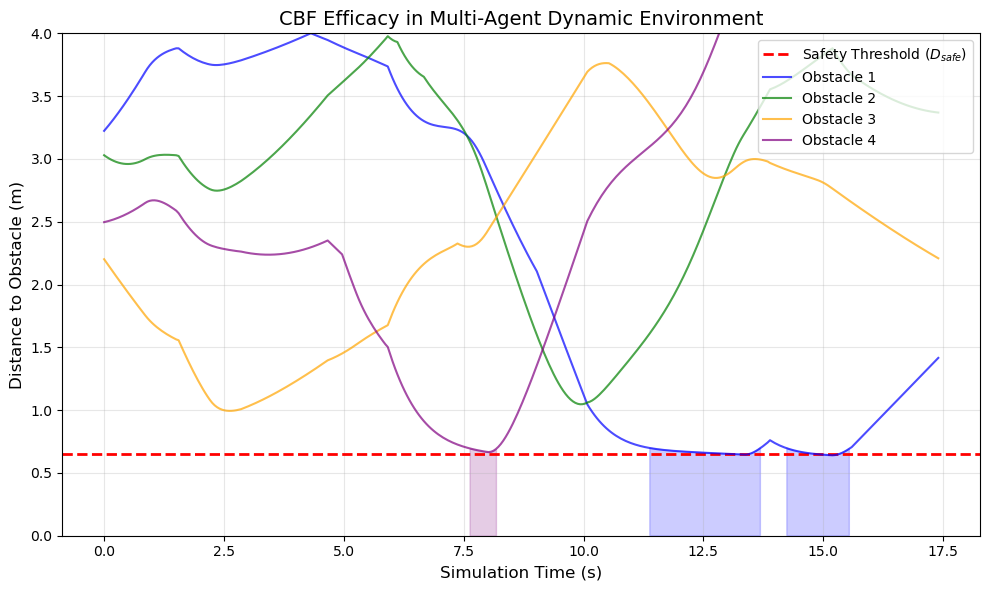

Multi-obstacle plot saved as 'cbf_multi_eval.png'


In [156]:
# Create the evaluation plot for all obstacles
steps_taken = len(dist_history[0])
time_axis = np.linspace(0, steps_taken * dt, steps_taken)

plt.figure(figsize=(10, 6))
plt.axhline(y=safe_distance, color='r', linestyle='--', label='Safety Threshold ($D_{safe}$)', linewidth=2)

# Plot distance to every obstacle
colors = ['blue', 'green', 'orange', 'purple']
for i in range(num_obs):
    plt.plot(time_axis, dist_history[i], color=colors[i%len(colors)], alpha=0.7, 
             label=f'Obstacle {i+1}')
    
    # Highlight active intervention regions
    dist_arr = np.array(dist_history[i])
    plt.fill_between(time_axis, 0, dist_arr, where=(dist_arr < safe_distance + 0.05), 
                     color=colors[i%len(colors)], alpha=0.2)

plt.title('CBF Efficacy in Multi-Agent Dynamic Environment', fontsize=14)
plt.xlabel('Simulation Time (s)', fontsize=12)
plt.ylabel('Distance to Obstacle (m)', fontsize=12)
plt.ylim(0, 4.0)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()

plt.savefig('cbf_multi_eval.png', dpi=300)
plt.show()
print("Multi-obstacle plot saved as 'cbf_multi_eval.png'")